In [262]:
# importing libraries
%matplotlib inline
!pip install plotly-express

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

In [263]:

# reading raw data file
columns = ['timestamp', 'accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']
dfs = list()

for file in os.listdir('./tcp_server/out_converted/15_05_test'):
    har_df = pd.read_csv('./tcp_server/out_converted/15_05_test/'+ file, header = 0, names = columns, on_bad_lines='skip')
    har_df['activity'] = file.split('.')[0]
    har_df['index'] = int(file.split('.')[1])
    dfs.append(har_df)

df = pd.concat(dfs, ignore_index=True)

# # removing null values
# har_df = har_df.dropna()
# har_df.shape

# # transforming the z-axis to float
# har_df['z-axis'] = har_df['z-axis'].str.replace(';', '')
# har_df['z-axis'] = har_df['z-axis'].apply(lambda x:float(x))

# # drop the rows where timestamp is 0
# df = har_df[har_df['timestamp'] != 0]

# now arrange data in ascending order of the user and timestamp
# df = df.sort_values(by = ['user', 'timestamp'], ignore_index=True)

In [264]:
print(df)

       timestamp  accX  accY   accZ  gyroX  gyroY  gyroZ  activity  index
0              8 -0.88  0.50  10.23   0.09  -0.02  -0.13     Break      1
1             26 -1.68  0.08   7.28  -0.21   0.04  -0.18     Break      1
2             46  0.04  0.08   7.97  -0.17  -0.08  -0.17     Break      1
3             67  2.57  0.15  12.41  -0.11   0.07  -0.12     Break      1
4             87 -0.84  0.23   8.20  -0.11   0.04  -0.11     Break      1
...          ...   ...   ...    ...    ...    ...    ...       ...    ...
48783       4921 -0.92 -1.34   8.35  -0.01   0.04   0.28  Straight     40
48784       4841 -1.84 -1.11  10.46  -0.08  -0.04   0.06  Straight     40
48785       4861  0.57 -1.84   7.62  -0.08  -0.04   0.06  Straight     40
48786       4882 -1.34 -1.38  11.19  -0.02   0.01   0.17  Straight     40
48787       4901  2.22 -1.49  11.84  -0.04   0.00   0.24  Straight     40

[48788 rows x 9 columns]


In [265]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-2**15,2**15-1))

scaler.fit(df.to_numpy()[:, [1,2,3,4,5,6]])

print(scaler.data_max_)
print(scaler.data_min_)

scaler.fit([[50,50,50,5,5,5],[-50,-50,-50,-5,-5,-5]])

print(scaler.data_max_)
print(scaler.data_min_)

print((df.to_numpy()[0:5, [1,2,3,4,5,6]]))

print(scaler.transform(df.to_numpy()[0:5, [1,2,3,4,5,6]]).astype(np.int16))

X_std = (0.5 - -50) / (100)
print(X_std)
X_scaled = X_std * (2**15-1 - -2**15) + -2**15
print(np.int16(X_scaled))

X_std = (0.08 - -50) / (100)
print(X_std)
X_scaled = X_std * (2**15-1 - -2**15) + -2**15
print(np.int16(X_scaled))


[27.81 11.26 40.5   1.52  1.82  1.96]
[-25.21 -14.18 -14.25  -1.14  -1.65  -2.07]
[50. 50. 50.  5.  5.  5.]
[-50. -50. -50.  -5.  -5.  -5.]
[[-0.88 0.5 10.23 0.09 -0.02 -0.13]
 [-1.68 0.08 7.28 -0.21 0.04 -0.18]
 [0.04 0.08 7.97 -0.17 -0.08 -0.17]
 [2.57 0.15 12.41 -0.11 0.07 -0.12]
 [-0.84 0.23 8.2 -0.11 0.04 -0.11]]
[[ -577   327  6703   589  -131  -852]
 [-1101    51  4770 -1376   261 -1180]
 [   25    51  5222 -1114  -524 -1114]
 [ 1683    97  8132  -721   458  -786]
 [ -550   150  5373  -721   261  -721]]
0.505
327
0.5008
51


In [266]:
print(df)
df[['accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']] = scaler.fit_transform(df[['accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']]).astype(np.int16)

print(df)

       timestamp  accX  accY   accZ  gyroX  gyroY  gyroZ  activity  index
0              8 -0.88  0.50  10.23   0.09  -0.02  -0.13     Break      1
1             26 -1.68  0.08   7.28  -0.21   0.04  -0.18     Break      1
2             46  0.04  0.08   7.97  -0.17  -0.08  -0.17     Break      1
3             67  2.57  0.15  12.41  -0.11   0.07  -0.12     Break      1
4             87 -0.84  0.23   8.20  -0.11   0.04  -0.11     Break      1
...          ...   ...   ...    ...    ...    ...    ...       ...    ...
48783       4921 -0.92 -1.34   8.35  -0.01   0.04   0.28  Straight     40
48784       4841 -1.84 -1.11  10.46  -0.08  -0.04   0.06  Straight     40
48785       4861  0.57 -1.84   7.62  -0.08  -0.04   0.06  Straight     40
48786       4882 -1.34 -1.38  11.19  -0.02   0.01   0.17  Straight     40
48787       4901  2.22 -1.49  11.84  -0.04   0.00   0.24  Straight     40

[48788 rows x 9 columns]
       timestamp  accX  accY  accZ  gyroX  gyroY  gyroZ  activity  index
0            

In [267]:
max = df[df['activity'] == 'Break'].max(axis='index')['index']
print(max)	

48


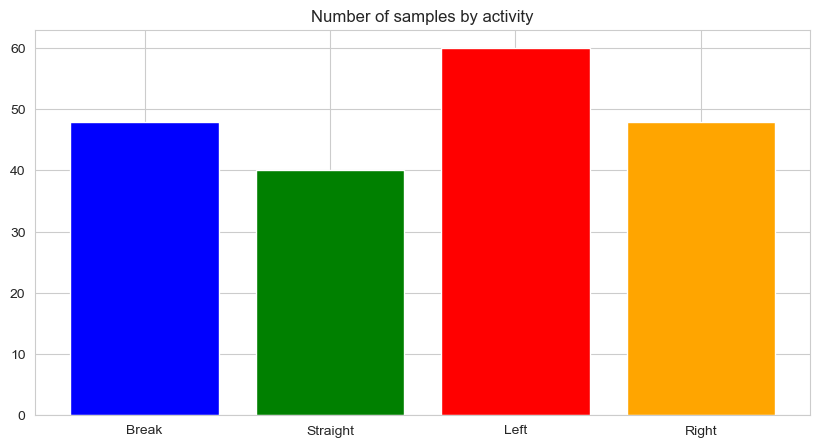

In [268]:
sns.set_style("whitegrid")
plt.figure(figsize = (10, 5))
max_break = df[df['activity'] == 'Break'].max(axis='index')['index']
max_straight = df[df['activity'] == 'Straight'].max(axis='index')['index']
max_left = df[df['activity'] == 'Left'].max(axis='index')['index']
max_right = df[df['activity'] == 'Right'].max(axis='index')['index']
plt.bar(['Break', 'Straight', 'Left', 'Right'], [max_break, max_straight, max_left, max_right], color = ['blue', 'green', 'red', 'orange'])
plt.title('Number of samples by activity')
plt.show()

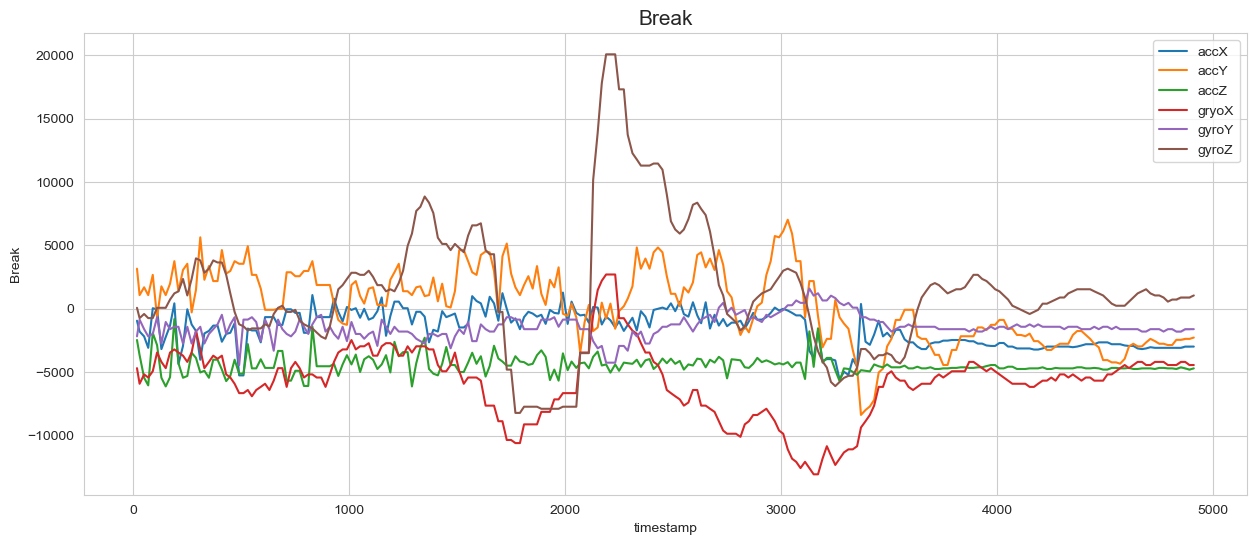

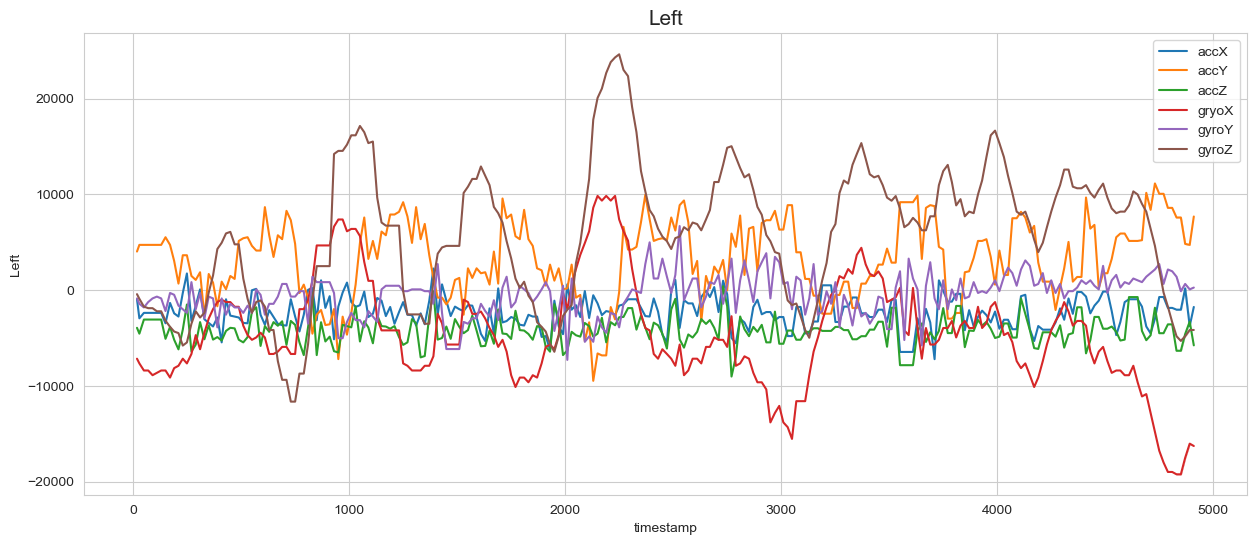

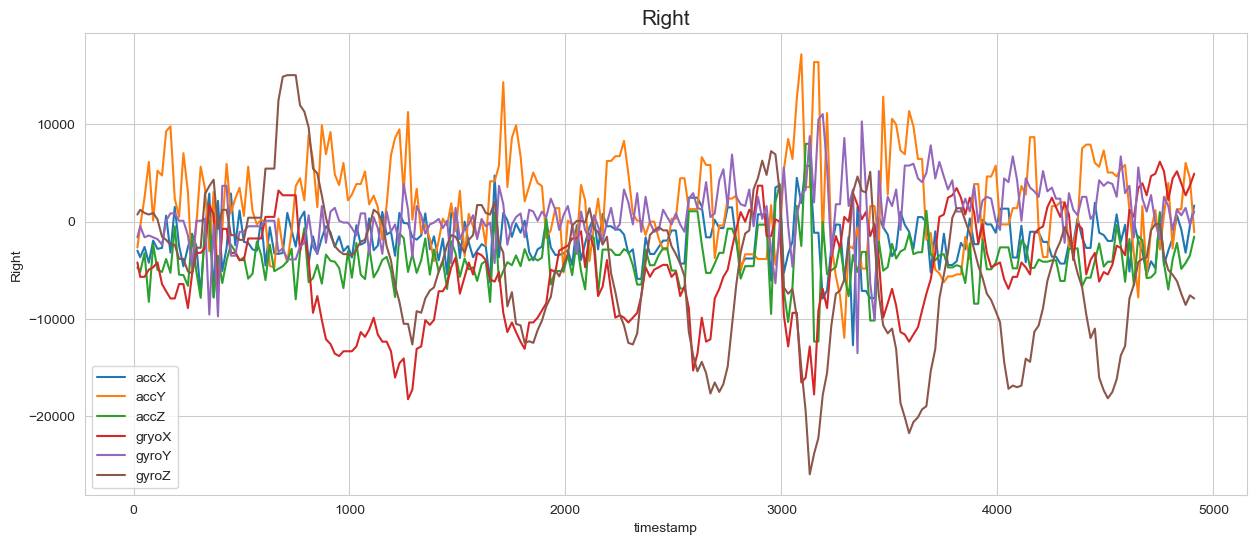

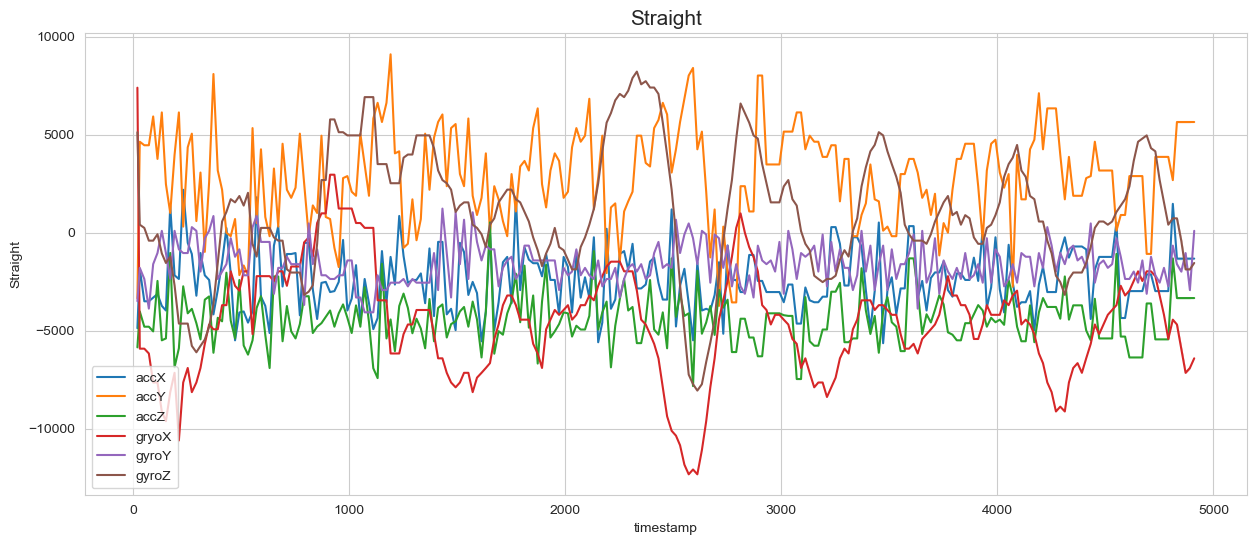

In [269]:
for i in ['Break', 'Left', 'Right', 'Straight']:
  data_36 = df[(df['index'] == 10) & (df['activity'] == i)][:400]
  plt.figure(figsize = (15, 6))
  sns.lineplot(y = 'accX', x = 'timestamp', data = data_36, label= 'accX')
  sns.lineplot(y = 'accY', x = 'timestamp', data = data_36, label= 'accY')
  sns.lineplot(y = 'accZ', x = 'timestamp', data = data_36, label= 'accZ')
  sns.lineplot(y = 'gyroX', x = 'timestamp', data = data_36, label= 'gryoX')
  sns.lineplot(y = 'gyroY', x = 'timestamp', data = data_36, label= 'gyroY')
  sns.lineplot(y = 'gyroZ', x = 'timestamp', data = data_36, label= 'gyroZ')
  plt.ylabel(i)
  plt.title(i, fontsize = 15)
  plt.show()

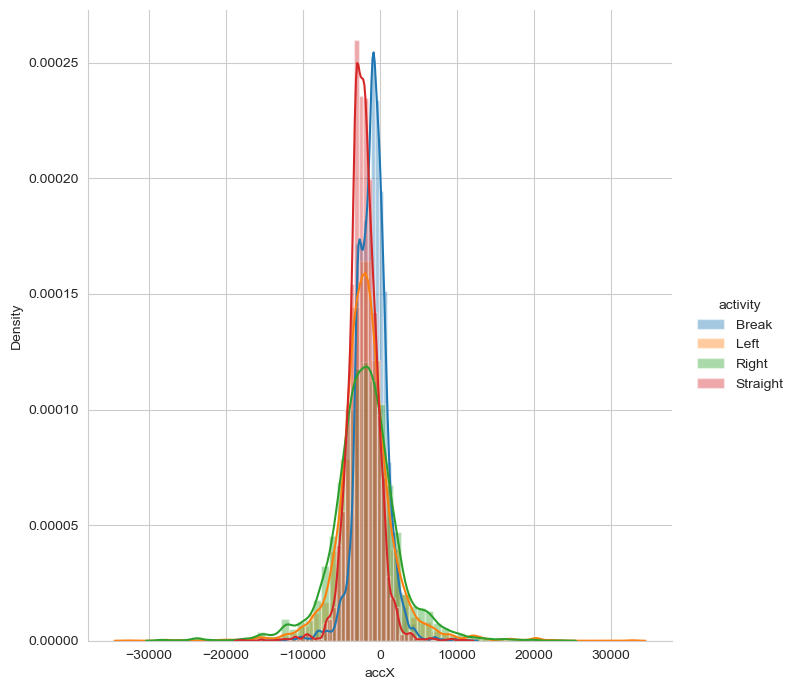

In [270]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accX').add_legend()
g.map(sns.scatterplot)

plt.show()

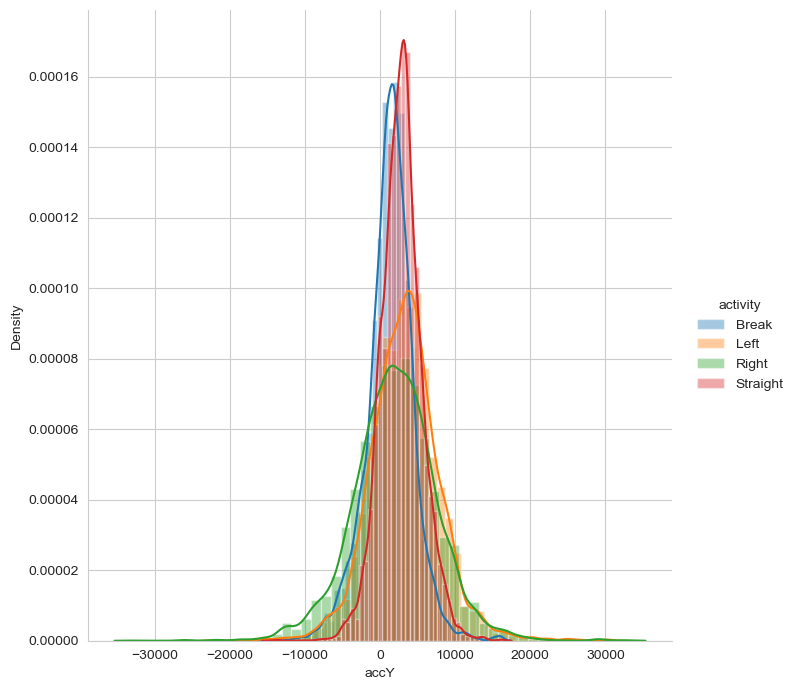

In [271]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accY').add_legend()
g.map(sns.scatterplot)
plt.show()

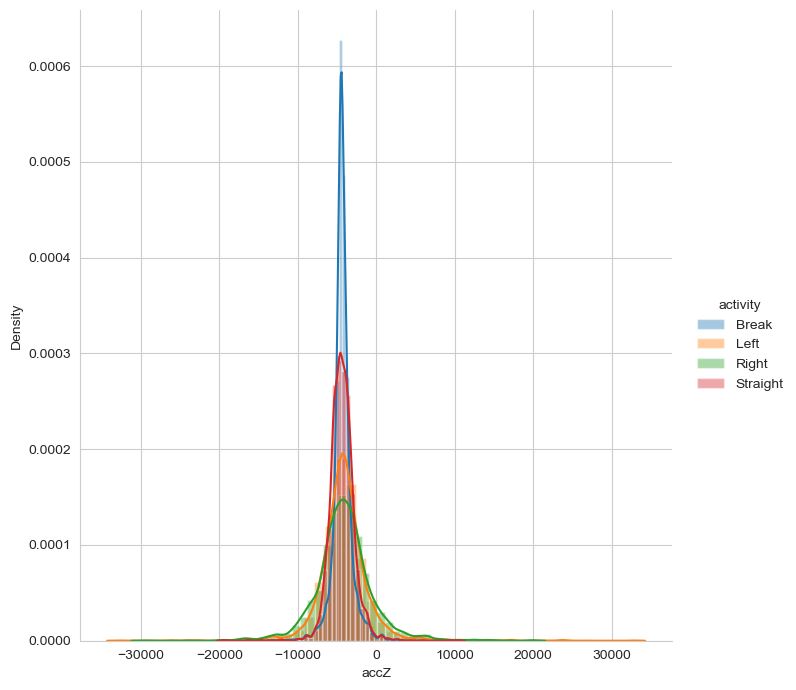

In [272]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accZ').add_legend()
g.map(sns.scatterplot)
plt.show()

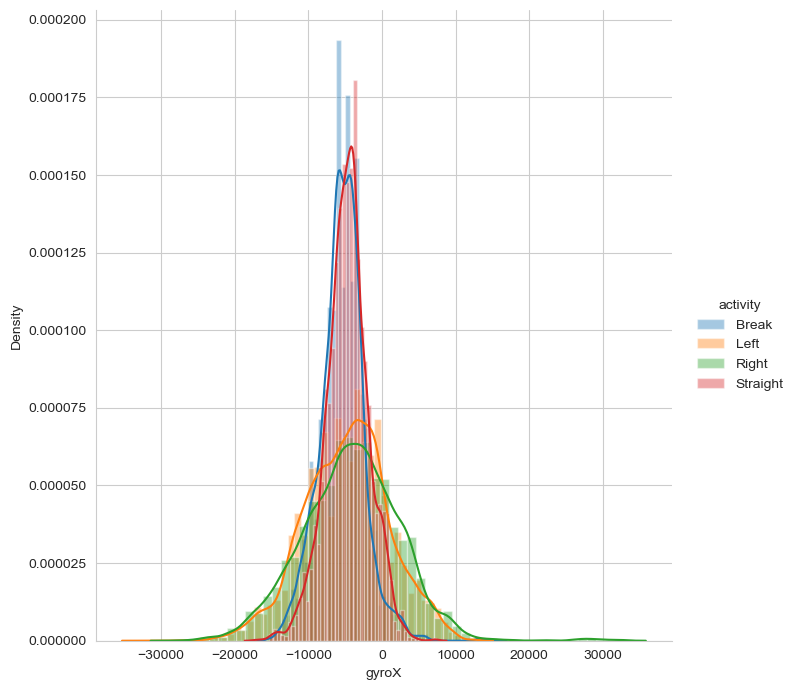

In [273]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroX').add_legend()
g.map(sns.scatterplot)
plt.show()

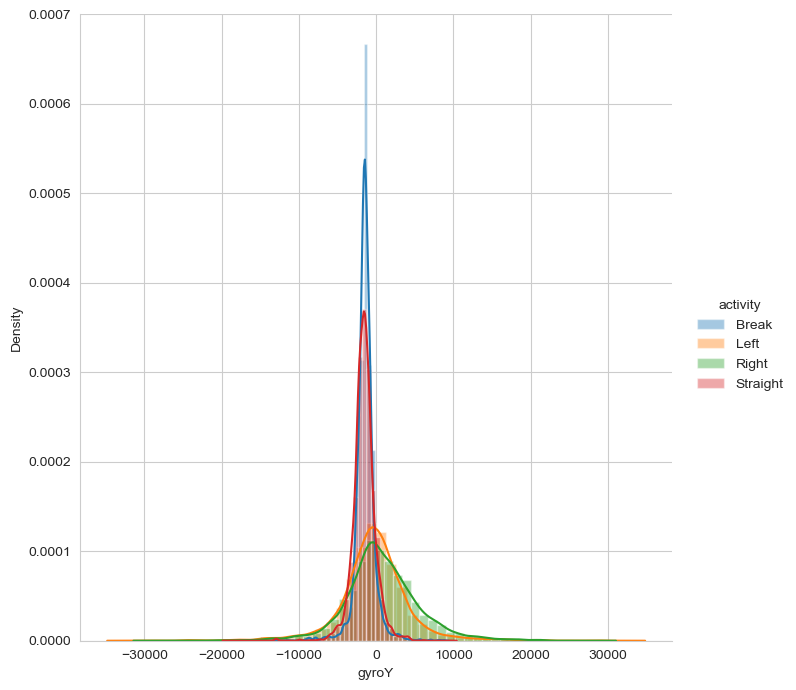

In [274]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroY').add_legend()
g.map(sns.scatterplot)
plt.show()

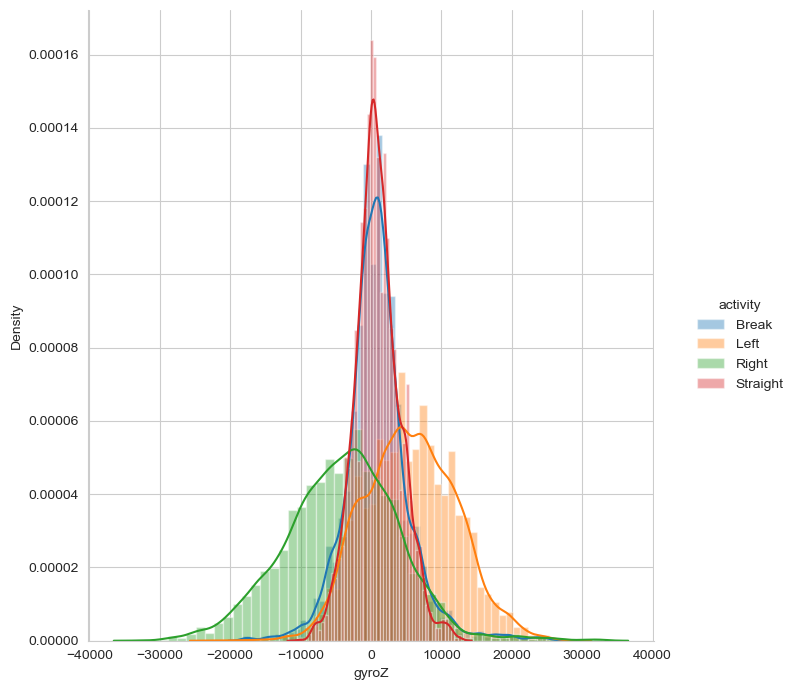

In [275]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroZ').add_legend()
g.map(sns.scatterplot)
plt.show()

In [276]:
# train data -> Users upto User ID = 27 (i.e. 27 users)


mask_train_break = (df['index'] <= (math.floor(max_break * 0.8))) & (df['activity'] == 'Break')
mask_train_straight = (df['index'] <= (math.floor(max_straight * 0.8))) & (df['activity'] == 'Straight')
mask_train_left = (df['index'] <= (math.floor(max_left * 0.8))) & (df['activity'] == 'Left')
mask_train_right = (df['index'] <= (math.floor(max_right * 0.8))) & (df['activity'] == 'Right')

df_train = pd.concat([df[mask_train_break], df[mask_train_straight], df[mask_train_left], df[mask_train_right]])

# test data -> Users from User ID = 28 to 36 (i.e. 9 users)
mask_test_break = (df['index'] > (math.floor(max_break * 0.8))) & (df['activity'] == 'Break')
mask_test_straight = (df['index'] > (math.floor(max_straight * 0.8))) & (df['activity'] == 'Straight')
mask_test_left = (df['index'] > (math.floor(max_left * 0.8))) & (df['activity'] == 'Left')
mask_test_right = (df['index'] > (math.floor(max_right * 0.8))) & (df['activity'] == 'Right')


df_test = pd.concat([df[mask_test_break], df[mask_test_straight], df[mask_test_left], df[mask_test_right]])

print(df_test)

       timestamp  accX   accY  accZ  gyroX  gyroY  gyroZ activity  index
9497          20   617   1983 -2603  -5420  -1416    568    Break     39
9498          36 -2077   2678 -3513  -4435  -1416   1056    Break     39
9499          57  -371   5048 -4207  -4188  -1983   2032    Break     39
9500          76 -2596   1004 -4519  -4435  -1605   2194    Break     39
9501          97  -655    901 -5117  -4188  -2172   2682    Break     39
...          ...   ...    ...   ...    ...    ...    ...      ...    ...
38785       4921    98   5331 -4471  -2956  -2738   7073    Right     48
38786       4840 -6155  11952 -8696      0   2360   7398    Right     48
38787       4861 -6155  11952 -8696  -6159  -4438   3658    Right     48
38788       4881  -470   5331 -4746  -1232  -5760   7723    Right     48
38789       4900 -2410   3657 -5847  -4435  -3683   5609    Right     48

[9798 rows x 9 columns]


In [277]:
xa_list = []
xg_list = []
ya_list = []
yg_list = []
za_list = []
zg_list = []
train_labels = []

window_size = 100
step_size = 50

# creating overlaping windows of size window-size 120
for i in range(0, df_train.shape[0] - window_size, step_size):
    xs_acc = df_train['accX'].values[i: i + window_size]
    ys_acc = df_train['accY'].values[i: i + window_size]
    zs_acc = df_train['accZ'].values[i: i + window_size]
    xs_gyro = df_train['gyroX'].values[i: i + window_size]
    ys_gyro = df_train['gyroY'].values[i: i + window_size]
    zs_gyro = df_train['gyroZ'].values[i: i + window_size]
    
    label = df_train['activity'][i: i + window_size].mode()[0]

    xa_list.append(xs_acc)
    xg_list.append(xs_gyro)
    ya_list.append(ys_acc)
    yg_list.append(ys_gyro)
    za_list.append(zs_acc)
    zg_list.append(zs_gyro)
    train_labels.append(label)

# Statistical Features on raw x, y and z in time domain
X_train = pd.DataFrame()

# mean
X_train['xa_mean'] = pd.Series(xa_list).apply(lambda x: x.mean())
X_train['ya_mean'] = pd.Series(ya_list).apply(lambda x: x.mean())
X_train['zg_mean'] = pd.Series(zg_list).apply(lambda x: x.mean())

# max
X_train['xg_max'] = pd.Series(xg_list).apply(lambda x: x.max())

# interquartile range
X_train['za_IQR'] = pd.Series(za_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# signal magnitude area
X_train['sma_gyro'] =    pd.Series(xg_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(yg_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(zg_list).apply(lambda x: np.sum(abs(x)/100))

In [278]:
xa_list = []
xg_list = []
ya_list = []
yg_list = []
za_list = []
zg_list = []
test_labels = []

# creating overlaping windows of size window-size 100
for i in range(0, df_test.shape[0] - window_size, step_size):
    xs_acc = df_test['accX'].values[i: i + window_size]
    ys_acc = df_test['accY'].values[i: i + window_size]
    zs_acc = df_test['accZ'].values[i: i + window_size]
    xs_gyro = df_test['gyroX'].values[i: i + window_size]
    ys_gyro = df_test['gyroY'].values[i: i + window_size]
    zs_gyro = df_test['gyroZ'].values[i: i + window_size]
    
    label = df_test['activity'][i: i + window_size].mode()[0]

    xa_list.append(xs_acc)
    xg_list.append(xs_gyro)
    ya_list.append(ys_acc)
    yg_list.append(ys_gyro)
    za_list.append(zs_acc)
    zg_list.append(zs_gyro)
    test_labels.append(label)

# Statistical Features on raw x, y and z in time domain
X_test = pd.DataFrame()

# mean
X_test['xa_mean'] = pd.Series(xa_list).apply(lambda x: x.mean())
X_test['ya_mean'] = pd.Series(ya_list).apply(lambda x: x.mean())
X_test['zg_mean'] = pd.Series(zg_list).apply(lambda x: x.mean())

# max
X_test['xg_max'] = pd.Series(xg_list).apply(lambda x: x.max())

# interquartile range
X_test['za_IQR'] = pd.Series(za_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# signal magnitude area
X_test['sma_gyro'] =    pd.Series(xg_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(yg_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(zg_list).apply(lambda x: np.sum(abs(x)/100))


In [279]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [280]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# logistic regression model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Classification Report-------------\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8247422680412371

 -------------Classification Report-------------

              precision    recall  f1-score   support

       Break       1.00      0.57      0.73        49
        Left       0.80      0.88      0.84        60
       Right       0.78      0.89      0.83        45
    Straight       0.80      0.97      0.88        40

    accuracy                           0.82       194
   macro avg       0.85      0.83      0.82       194
weighted avg       0.85      0.82      0.82       194



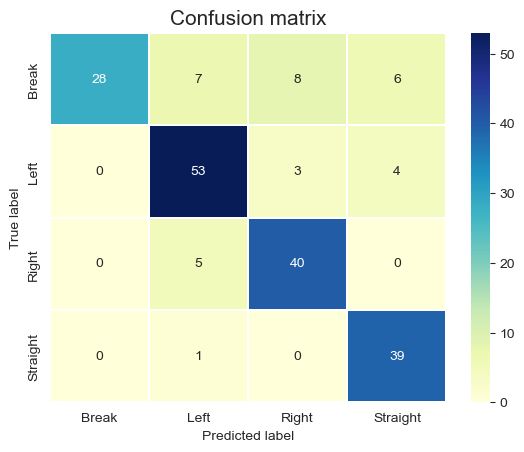

In [281]:
labels = ['Break', 'Left', 'Right', 'Straight']
confusion_Matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_Matrix, xticklabels=labels, yticklabels=labels, annot=True,linewidths = 0.1, fmt="d", cmap = 'YlGnBu')
plt.title("Confusion matrix", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

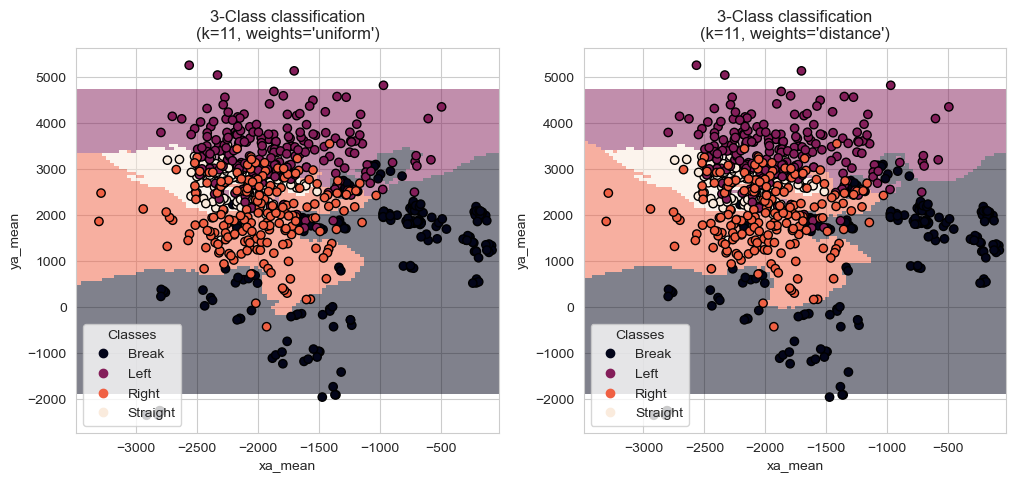

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

colors = ['Break', 'Left', 'Right', 'Straight']
n_classes = ['Break', 'Left', 'Right', 'Straight']
color = []

for i in y_train:
    color.append(colors.index(i))

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=11))]
)

from sklearn.inspection import DecisionBoundaryDisplay

X = X_train.to_numpy()[:,[0,1]]


_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test.to_numpy()[:, [0,1]],
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=X_train.columns[0],
        ylabel=X_train.columns[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X[:, 0], X[:, 1], c=color, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        colors,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

In [283]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Evaluate the model
accuracy_before = rf.score(X_test, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Classification Report-------------\n")
print(classification_report(y_test, y_pred))

Accuracy before feature selection: 0.78
Accuracy: 0.7835051546391752

 -------------Classification Report-------------

              precision    recall  f1-score   support

       Break       1.00      0.76      0.86        49
        Left       0.69      0.68      0.69        60
       Right       0.68      0.93      0.79        45
    Straight       0.89      0.80      0.84        40

    accuracy                           0.78       194
   macro avg       0.82      0.79      0.79       194
weighted avg       0.81      0.78      0.79       194



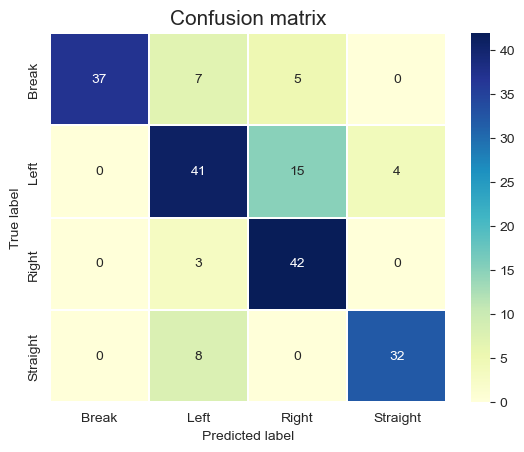

In [285]:
labels = ['Break', 'Left', 'Right', 'Straight']
confusion_Matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_Matrix, xticklabels=labels, yticklabels=labels, annot=True,linewidths = 0.1, fmt="d", cmap = 'YlGnBu')
plt.title("Confusion matrix", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

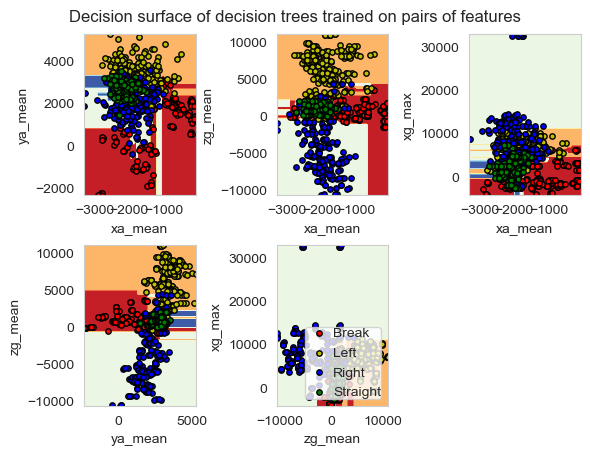

In [286]:
from sklearn.inspection import DecisionBoundaryDisplay

# Parameters
n_classes = ['Break', 'Left', 'Right', 'Straight']
plot_colors = "rybg"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [2, 3]]):
    # We only take the two corresponding features
    X = X_train.to_numpy()[:,pair]
    y = y_train

    # Train
    clf = RandomForestClassifier(n_estimators=10, max_depth=10, max_features=2, random_state=1).fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=X_train.columns[pair[0]],
        ylabel=X_train.columns[pair[1]],
    )

    # Plot the training points
    for i, color in zip(n_classes, plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=i,
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

plt.show()

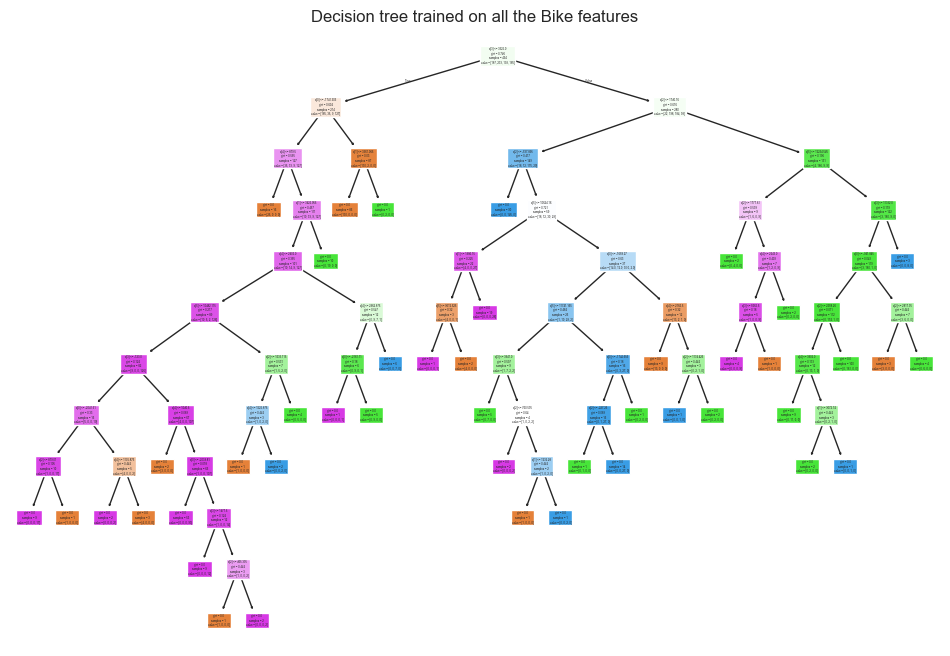

In [287]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(rf.estimators_[0], filled=True)
plt.title("Decision tree trained on all the Bike features")
plt.show()

In [ ]:
import emlearn
import shutil

cmodel_rf = emlearn.convert(rf, method='loadable')

cmodel_rf.save(file='./random_forest_model.h', name='random_forest_model')

shutil.copyfile('./random_forest_model.h', '.\Implementation\Implementation\src/random_forest_model.h')



'.\\Implementation\\Implementation\\src/random_forest_model.h'

In [289]:
from sklearn.metrics import f1_score

pred_py_rf = rf.predict(X_test)
pred_c_rf = cmodel_rf.predict(X_test)

activitys = ['Break', 'Left', 'Right', 'Straight']

temp = []

for i in pred_c_rf:
    temp.append(activitys[i])

pred_c_rf = temp

val_score_rf = f1_score(y_test, pred_py_rf, average='weighted')
c_val_score_rf = f1_score(y_test, pred_c_rf, average='weighted')

print(f"Python model F1 score: {val_score_rf}")
print(f"C model F1 score: {c_val_score_rf}")


Python model F1 score: 0.7861785662002814
C model F1 score: 0.791275147332375


In [290]:
# cmodel_knn = emlearn.convert(knn,  method='loadable')

In [291]:

# pred_py_knn = knn.predict(X_test)
# pred_c_knn = cmodel_knn.predict(X_test)

# activitys = ['Break', 'Left', 'Right', 'Straight']

# temp = []

# for i in pred_c_knn:
#     temp.append(activitys[i])

# pred_c_knn = temp


In [292]:

# val_score_knn = f1_score(y_test, pred_py_knn, average='weighted')
# c_val_score_knn = f1_score(y_test, pred_c_knn, average='weighted')

# print(f"Python model F1 score: {val_score_knn}")
# print(f"C model F1 score: {c_val_score_knn}")